In [1]:
%load_ext autoreload
%autoreload 2

# Trade Strategy 20250603

## Description
Combine various individual strategies and assets to create a portfolio.

## Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from utils.data_fetcher import TickerPriceDataFetcher
import os
from indicators.volatility import calculate_atr, calculate_forward_vol
from indicators.returns import calculate_returns, calculate_forward_returns, calculate_MA_returns
from utils.helpers import PercentileScaler
import datetime
from sklearn.linear_model import LinearRegression
from utils.backtester import BackTester
import backtrader as bt
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from pypfopt.hierarchical_portfolio import HRPOpt
from pypfopt.plotting import plot_dendrogram
from pypfopt import risk_models
from scipy import stats

Warning - Certain functionality 
             requires requests_html, which is not installed.
             
             Install using: 
             pip install requests_html
             
             After installation, you may have to restart your Python session.


c:\Users\alexr\AlgoTester\utils\data_fetcher.py:19: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


## Utils

### Helpers

In [3]:
def normalize_weights(weights):
    total_weight = sum(weights.values())
    normalized_weights = {ticker: weight / total_weight for ticker, weight in weights.items()}
    return normalized_weights

def gmean(arr):
    return np.exp(np.mean(np.log(arr)))

def hmean(arr):
    return 1 / np.mean(1 / arr)

## Load Data

In [25]:
# lookforward_period = 21
lookforward_period = 100
lookback_periods=[21, 100, 200, 252]
rebalance_period=21
atr_period = 21
covariance_matrix_lookback = 252
vol_target = 0.1
current_date = datetime.datetime.now().date()
current_date = current_date.strftime("%Y%m%d")

tickers_to_fetch = ['IB01.L', 'SHV', 'SPY', 'TLT', 'GLD', '^VIX', '^GVZ', 'PPLT', 'URA', 'DBA', 'EEM', 'LQD', 'IBIT', 'USO']
fetcher = TickerPriceDataFetcher()
price_data = fetcher.load_data(ticker_list=tickers_to_fetch)

for ticker in price_data:
    print(ticker)
    display(price_data[ticker])
# cash_asset = {'ticker': 'IB01.L', 'data': price_data['IB01.L']}


2025-06-29 17:10:14,594 - utils.data_fetcher - INFO - Loading data for ['IB01.L', 'SHV', 'SPY', 'TLT', 'GLD', '^VIX', '^GVZ', 'PPLT', 'URA', 'DBA', 'EEM', 'LQD', 'IBIT', 'USO']
2025-06-29 17:10:14,595 - utils.data_fetcher - INFO - Data for IB01.L already exists
2025-06-29 17:10:14,596 - utils.data_fetcher - INFO - Data for SHV already exists
2025-06-29 17:10:14,598 - utils.data_fetcher - INFO - Data for SPY already exists
2025-06-29 17:10:14,599 - utils.data_fetcher - INFO - Data for TLT already exists
2025-06-29 17:10:14,600 - utils.data_fetcher - INFO - Data for GLD already exists
2025-06-29 17:10:14,601 - utils.data_fetcher - INFO - Data for ^VIX already exists
2025-06-29 17:10:14,603 - utils.data_fetcher - INFO - Data for ^GVZ already exists
2025-06-29 17:10:14,604 - utils.data_fetcher - INFO - Data for PPLT already exists
2025-06-29 17:10:14,605 - utils.data_fetcher - INFO - Data for URA already exists
2025-06-29 17:10:14,606 - utils.data_fetcher - INFO - Data for DBA already exis

IB01.L


,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains
Date,,,,,,,,,
2019-02-20,5.000000,5.000000,5.000000,5.000000,5.000000,0,0.0,0.0,0.0
2019-02-21,5.000000,5.000000,5.000000,5.000000,5.000000,0,0.0,0.0,0.0
2019-02-22,99.192108,99.192108,99.192108,99.192108,99.192108,0,0.0,0.0,0.0
2019-02-25,99.192108,99.192108,99.192108,99.192108,99.192108,0,0.0,0.0,0.0
2019-02-26,99.192108,99.192108,99.192108,99.192108,99.192108,0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
2025-06-23,116.220001,116.239998,116.188004,116.239998,116.239998,349683,0.0,0.0,0.0
2025-06-24,116.239998,116.332001,116.220001,116.239998,116.239998,260665,0.0,0.0,0.0
2025-06-25,116.239998,116.491997,116.008003,116.260002,116.260002,249787,0.0,0.0,0.0


SHV


,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains
Date,,,,,,,,,
2007-01-11,108.699997,108.699997,108.699997,108.699997,84.503433,900,0.0,0.0,0.0
2007-01-12,108.760002,108.760002,108.760002,108.760002,84.550079,1100,0.0,0.0,0.0
2007-01-16,108.760002,108.760002,108.739998,108.739998,84.534500,500,0.0,0.0,0.0
2007-01-17,108.800003,108.800003,108.800003,108.800003,84.581139,8200,0.0,0.0,0.0
2007-01-18,108.800003,108.800003,108.760002,108.790001,84.573402,23100,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
2025-06-23,110.330002,110.339996,110.320000,110.339996,110.339996,2763100,0.0,0.0,0.0
2025-06-24,110.349998,110.349998,110.339996,110.349998,110.349998,2718800,0.0,0.0,0.0
2025-06-25,110.370003,110.370003,110.360001,110.360001,110.360001,2772100,0.0,0.0,0.0


...

,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains
Date,,,,,,,,,
2002-07-30,101.300003,102.000000,101.250000,101.370003,38.517559,21200,0.0,0.0,0.0
2002-07-31,101.800003,102.250000,101.550003,101.989998,38.753094,272000,0.0,0.0,0.0
2002-08-01,102.400002,103.099998,102.300003,102.989998,39.133068,111700,0.0,0.0,0.0
2002-08-02,102.900002,103.300003,102.449997,103.199997,39.212856,29200,0.0,0.0,0.0
2002-08-05,103.650002,103.650002,102.510002,102.949997,39.117889,166500,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
2025-06-23,108.389999,108.699997,108.309998,108.410004,108.410004,34072400,0.0,0.0,0.0
2025-06-24,108.279999,109.019997,108.269997,108.919998,108.919998,38185300,0.0,0.0,0.0
2025-06-25,108.709999,108.849998,108.529999,108.790001,108.790001,30675200,0.0,0.0,0.0


IBIT


,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains
Date,,,,,,,,,
2024-01-11,27.940001,30.000000,26.280001,26.629999,26.629999,37657300,0.0,0.0,0.0
2024-01-12,26.400000,26.410000,24.750000,24.969999,24.969999,22846800,0.0,0.0,0.0
2024-01-16,24.700001,24.862000,24.040001,24.719999,24.719999,15078200,0.0,0.0,0.0
2024-01-17,24.350000,24.559999,24.150000,24.410000,24.410000,13964500,0.0,0.0,0.0
2024-01-18,24.350000,24.469999,23.200001,23.340000,23.340000,17823200,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
2025-06-23,57.480000,58.759998,56.625000,58.669998,58.669998,63747200,0.0,0.0,0.0
2025-06-24,59.770000,60.470001,59.555000,60.060001,60.060001,40387200,0.0,0.0,0.0
2025-06-25,61.330002,61.525002,60.709999,61.275002,61.275002,40812500,0.0,0.0,0.0


USO


,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains
Date,,,,,,,,,
2006-04-10,546.000000,548.000000,541.359985,544.159973,544.159973,484738,0.0,0.0,0.0
2006-04-11,546.559998,547.119995,538.400024,545.599976,545.599976,162138,0.0,0.0,0.0
2006-04-12,545.760010,550.479980,542.479980,542.719971,542.719971,156038,0.0,0.0,0.0
2006-04-13,540.000000,551.919983,539.200012,550.559998,550.559998,70088,0.0,0.0,0.0
2006-04-17,553.599976,559.200012,549.440002,558.320007,558.320007,114713,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
2025-06-23,83.250000,83.570000,76.410004,76.410004,76.410004,50659400,0.0,0.0,0.0
2025-06-24,73.339996,73.860001,71.970001,73.000000,73.000000,16119600,0.0,0.0,0.0
2025-06-25,72.930000,74.230003,72.790001,73.309998,73.309998,12401000,0.0,0.0,0.0


## Process Data

In [29]:
def process_price_data(df, lookforward_period=100, atr_period=21, lookback_periods=[21, 100, 200, 252], vix_ticker=None):
    # Calculate indicators
    df['returns'] = df['close'].pct_change()
    df['vol_forward'] = calculate_forward_vol(df, lookforward_period)
    df['ret_forward'] = calculate_forward_returns(df, lookforward_period)
    df['ATR'] = calculate_atr(df, atr_period)
    df['var_forward'] = df['vol_forward'] ** 2
    if vix_ticker is not None:
        df['VIX'] = price_data[vix_ticker]['close'].copy()
    for period in lookback_periods:
        df['MA_{}'.format(period)] = calculate_MA_returns(df, period)
    return df


risky_assets = dict()

# SPY - US equities
risky_assets['SPY'] = dict()
df = price_data['SPY'].copy()
risky_assets['SPY']['data'] = process_price_data(df, vix_ticker='^VIX')
display(risky_assets['SPY']['data'])

# TLT - US treasury bonds
risky_assets['TLT'] = dict()
df = price_data['TLT'].copy()
risky_assets['TLT']['data'] = process_price_data(df)
display(risky_assets['TLT']['data'])

# GLD - Gold
risky_assets['GLD'] = dict()
df = price_data['GLD'].copy()
risky_assets['GLD']['data'] = process_price_data(df, vix_ticker='^GVZ')
display(risky_assets['GLD']['data'])

# EEM - Emerging markets
risky_assets['EEM'] = dict()
df = price_data['EEM'].copy()
risky_assets['EEM']['data'] = process_price_data(df)
display(risky_assets['EEM']['data'])

# DBA - Agriculture
risky_assets['DBA'] = dict()
df = price_data['DBA'].copy()
risky_assets['DBA']['data'] = process_price_data(df)
display(risky_assets['DBA']['data'])

# LQD - US corporate bonds
risky_assets['LQD'] = dict()
df = price_data['LQD'].copy()
risky_assets['LQD']['data'] = process_price_data(df)
display(risky_assets['LQD']['data'])

# IBIT - Bitcoin
risky_assets['IBIT'] = dict()
df = price_data['IBIT'].copy()
risky_assets['IBIT']['data'] = process_price_data(df)
display(risky_assets['IBIT']['data'])

# PPLT - platinum
risky_assets['PPLT'] = dict()
df = price_data['PPLT'].copy()
risky_assets['PPLT']['data'] = process_price_data(df)
display(risky_assets['PPLT']['data'])

# URA - uranium
risky_assets['URA'] = dict()
df = price_data['URA'].copy()
risky_assets['URA']['data'] = process_price_data(df)
display(risky_assets['URA']['data'])

# USO - oil
risky_assets['USO'] = dict()
df = price_data['USO'].copy()
risky_assets['USO']['data'] = process_price_data(df)
display(risky_assets['USO']['data'])



,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,returns,vol_forward,ret_forward,ATR,var_forward,VIX,MA_21,MA_100,MA_200,MA_252
Date,,,,,,,,,,,,,,,,,,,
1993-01-29,43.968750,43.968750,43.750000,43.937500,24.380444,1003200,0.0,0.0,0.0,NaN,0.112489,-0.000706,NaN,0.012654,12.42,NaN,NaN,NaN,NaN
1993-02-01,43.968750,44.250000,43.968750,44.250000,24.553835,480500,0.0,0.0,0.0,0.007112,0.113916,0.010571,0.007112,0.012977,12.33,NaN,NaN,NaN,NaN
1993-02-02,44.218750,44.375000,44.125000,44.343750,24.605856,201300,0.0,0.0,0.0,0.002119,0.113880,-0.000697,0.006934,0.012969,12.25,NaN,NaN,NaN,NaN
1993-02-03,44.406250,44.843750,44.375000,44.812500,24.865978,529400,0.0,0.0,0.0,0.010571,0.114021,0.006250,0.007315,0.013001,12.12,NaN,NaN,NaN,NaN
1993-02-04,44.968750,45.093750,44.468750,45.000000,24.970007,531500,0.0,0.0,0.0,0.004184,0.114103,0.002085,0.007848,0.013019,12.29,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-23,595.039978,600.539978,591.890015,600.150024,600.150024,87426000,0.0,0.0,0.0,0.009877,NaN,NaN,0.011441,NaN,19.83,0.008705,0.042971,0.034539,0.046205
2025-06-24,604.330017,607.849976,603.409973,606.780029,606.780029,67735300,0.0,0.0,0.0,0.011047,NaN,NaN,0.011466,NaN,17.48,0.017918,0.054402,0.045465,0.057326
2025-06-25,607.909973,608.609985,605.539978,607.119995,607.119995,62114800,0.0,0.0,0.0,0.000560,NaN,NaN,0.010769,NaN,16.76,0.016215,0.054954,0.045533,0.057460


,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,returns,vol_forward,ret_forward,ATR,var_forward,MA_21,MA_100,MA_200,MA_252
Date,,,,,,,,,,,,,,,,,,
2002-07-30,81.750000,81.900002,81.519997,81.519997,37.608505,6100,0.0,0.0,0.0,NaN,0.129688,0.058040,NaN,0.016819,NaN,NaN,NaN,NaN
2002-07-31,81.949997,82.800003,81.900002,82.529999,38.074451,29400,0.0,0.0,0.0,0.012390,0.128345,0.052771,0.015702,0.016472,NaN,NaN,NaN,NaN
2002-08-01,82.540001,83.019997,82.540001,83.000000,38.291264,25000,0.0,0.0,0.0,0.005695,0.128088,0.042338,0.014639,0.016407,NaN,NaN,NaN,NaN
2002-08-02,83.160004,84.099998,82.879997,83.849998,38.683422,52800,0.0,0.0,0.0,0.010241,0.127412,0.043576,0.014569,0.016234,NaN,NaN,NaN,NaN
2002-08-05,84.040001,84.440002,83.849998,84.220001,38.854107,61100,0.0,0.0,0.0,0.004413,0.127280,0.054611,0.013750,0.016200,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-23,86.930000,87.440002,86.769997,86.769997,86.769997,36851800,0.0,0.0,0.0,0.003237,NaN,NaN,0.011349,NaN,0.010257,-0.017510,-0.040623,-0.050368
2025-06-24,86.470001,87.589996,86.430000,87.400002,87.400002,32959100,0.0,0.0,0.0,0.007261,NaN,NaN,0.011499,NaN,0.015908,-0.010308,-0.033037,-0.043200
2025-06-25,87.110001,87.510002,86.800003,87.510002,87.510002,26345300,0.0,0.0,0.0,0.001259,NaN,NaN,0.011117,NaN,0.015523,-0.008969,-0.031173,-0.041728


,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,returns,vol_forward,ret_forward,ATR,var_forward,VIX,MA_21,MA_100,MA_200,MA_252
Date,,,,,,,,,,,,,,,,,,,
2004-11-18,44.430000,44.490002,44.070000,44.380001,44.380001,5992000,0.0,0.0,0.0,NaN,0.120535,-0.055158,NaN,0.014529,NaN,NaN,NaN,NaN,NaN
2004-11-19,44.490002,44.919998,44.470001,44.779999,44.779999,11655300,0.0,0.0,0.0,0.009013,0.119661,-0.056730,0.012168,0.014319,NaN,NaN,NaN,NaN,NaN
2004-11-22,44.750000,44.970001,44.740002,44.950001,44.950001,11996000,0.0,0.0,0.0,0.003796,0.120033,-0.046034,0.011430,0.014408,NaN,NaN,NaN,NaN,NaN
2004-11-23,44.880001,44.919998,44.720001,44.750000,44.750000,3169200,0.0,0.0,0.0,-0.004449,0.121967,-0.039290,0.010816,0.014876,NaN,NaN,NaN,NaN,NaN
2004-11-24,44.930000,45.049999,44.790001,45.049999,45.049999,6105100,0.0,0.0,0.0,0.006704,0.121555,-0.041731,0.010486,0.014776,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-23,310.339996,312.670013,310.309998,311.079987,311.079987,12687900,0.0,0.0,0.0,0.003063,NaN,NaN,0.012578,NaN,19.020000,0.007857,0.077244,0.165753,0.205951
2025-06-24,305.070007,306.339996,303.540009,306.190002,306.190002,12035200,0.0,0.0,0.0,-0.015719,NaN,NaN,0.013603,NaN,18.280001,-0.008457,0.058405,0.145801,0.185389
2025-06-25,305.309998,307.359985,305.119995,307.119995,307.119995,6733200,0.0,0.0,0.0,0.003037,NaN,NaN,0.013229,NaN,17.330000,-0.005042,0.059822,0.147676,0.187305


,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,returns,vol_forward,ret_forward,ATR,var_forward,MA_21,MA_100,MA_200,MA_252
Date,,,,,,,,,,,,,,,,,,
2003-04-14,11.144444,11.222222,11.144444,11.222222,7.340265,93600,0.0,0.0,0.0,NaN,0.175648,0.372994,NaN,0.030852,NaN,NaN,NaN,NaN
2003-04-15,11.291111,11.388889,11.291111,11.355556,7.427477,421200,0.0,0.0,0.0,0.011881,0.176865,0.383053,0.014852,0.031281,NaN,NaN,NaN,NaN
2003-04-16,11.477778,11.533333,11.477778,11.486667,7.513233,9000,0.0,0.0,0.0,0.011546,0.179391,0.349405,0.014766,0.032181,NaN,NaN,NaN,NaN
2003-04-17,11.550000,11.572222,11.530000,11.568889,7.567013,17100,0.0,0.0,0.0,0.007158,0.181971,0.327441,0.013948,0.033113,NaN,NaN,NaN,NaN
2003-04-21,11.582222,11.583333,11.555556,11.564444,7.564109,72900,0.0,0.0,0.0,-0.000384,0.182010,0.321459,0.012808,0.033128,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-23,46.250000,46.720001,46.150002,46.709999,46.709999,22233200,0.0,0.0,0.0,0.008202,NaN,NaN,0.010199,NaN,0.001859,0.052174,0.059407,0.065505
2025-06-24,47.439999,47.939999,47.410000,47.919998,47.919998,36113900,0.0,0.0,0.0,0.025904,NaN,NaN,0.011590,NaN,0.025842,0.078111,0.086183,0.092602
2025-06-25,47.900002,47.990002,47.820000,47.959999,47.959999,23739200,0.0,0.0,0.0,0.000835,NaN,NaN,0.010593,NaN,0.024891,0.077859,0.086425,0.092991


,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,returns,vol_forward,ret_forward,ATR,var_forward,MA_21,MA_100,MA_200,MA_252
Date,,,,,,,,,,,,,,,,,,
2007-01-05,24.930000,25.049999,24.850000,25.020000,21.559395,27800,0.0,0.0,0.0,NaN,0.230601,0.054844,NaN,0.053177,NaN,NaN,NaN,NaN
2007-01-08,25.940001,25.940001,24.840000,24.980000,21.524927,143600,0.0,0.0,0.0,-0.001599,0.230577,0.070154,0.043965,0.053166,NaN,NaN,NaN,NaN
2007-01-09,24.799999,24.820000,24.600000,24.660000,21.249186,136700,0.0,0.0,0.0,-0.012810,0.229830,0.060655,0.041415,0.052822,NaN,NaN,NaN,NaN
2007-01-10,24.700001,24.820000,24.500000,24.730000,21.309505,76600,0.0,0.0,0.0,0.002839,0.229835,0.048207,0.039318,0.052824,NaN,NaN,NaN,NaN
2007-01-11,24.900000,25.129999,24.799999,25.100000,21.628330,159600,0.0,0.0,0.0,0.014962,0.229074,-0.036531,0.037113,0.052475,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-23,26.370001,26.580000,26.370001,26.480000,26.480000,569100,0.0,0.0,0.0,0.002650,NaN,NaN,0.010198,NaN,-0.017040,-0.018212,-0.002080,0.017051
2025-06-24,26.280001,26.469999,26.280001,26.290001,26.290001,405700,0.0,0.0,0.0,-0.007175,NaN,NaN,0.009933,NaN,-0.022175,-0.024667,-0.009610,0.009527
2025-06-25,26.270000,26.270000,26.030001,26.080000,26.080000,228000,0.0,0.0,0.0,-0.007988,NaN,NaN,0.009995,NaN,-0.028161,-0.031869,-0.017815,0.001236


,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,returns,vol_forward,ret_forward,ATR,var_forward,MA_21,MA_100,MA_200,MA_252
Date,,,,,,,,,,,,,,,,,,
2002-07-30,101.300003,102.000000,101.250000,101.370003,38.517559,21200,0.0,0.0,0.0,NaN,0.072811,0.062653,NaN,0.005301,NaN,NaN,NaN,NaN
2002-07-31,101.800003,102.250000,101.550003,101.989998,38.753094,272000,0.0,0.0,0.0,0.006116,0.072295,0.052627,0.008681,0.005227,NaN,NaN,NaN,NaN
2002-08-01,102.400002,103.099998,102.300003,102.989998,39.133068,111700,0.0,0.0,0.0,0.009805,0.070797,0.050678,0.008833,0.005012,NaN,NaN,NaN,NaN
2002-08-02,102.900002,103.300003,102.449997,103.199997,39.212856,29200,0.0,0.0,0.0,0.002039,0.070801,0.055464,0.008703,0.005013,NaN,NaN,NaN,NaN
2002-08-05,103.650002,103.650002,102.510002,102.949997,39.117889,166500,0.0,0.0,0.0,-0.002422,0.070779,0.062573,0.008900,0.005010,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-23,108.389999,108.699997,108.309998,108.410004,108.410004,34072400,0.0,0.0,0.0,0.002497,NaN,NaN,0.005726,NaN,0.008470,0.007433,-0.001861,-0.003345
2025-06-24,108.279999,109.019997,108.269997,108.919998,108.919998,38185300,0.0,0.0,0.0,0.004704,NaN,NaN,0.005822,NaN,0.011994,0.012046,0.002969,0.001314
2025-06-25,108.709999,108.849998,108.529999,108.790001,108.790001,30675200,0.0,0.0,0.0,-0.001194,NaN,NaN,0.005593,NaN,0.009665,0.010746,0.001938,0.000094


,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,returns,vol_forward,ret_forward,ATR,var_forward,MA_21,MA_100,MA_200,MA_252
Date,,,,,,,,,,,,,,,,,,
2024-01-11,27.940001,30.000000,26.280001,26.629999,26.629999,37657300,0.0,0.0,0.0,NaN,0.565165,0.628754,NaN,0.319412,NaN,NaN,NaN,NaN
2024-01-12,26.400000,26.410000,24.750000,24.969999,24.969999,22846800,0.0,0.0,0.0,-0.062336,0.555635,0.624596,0.070597,0.308731,NaN,NaN,NaN,NaN
2024-01-16,24.700001,24.862000,24.040001,24.719999,24.719999,15078200,0.0,0.0,0.0,-0.010012,0.556381,0.614912,0.071832,0.309560,NaN,NaN,NaN,NaN
2024-01-17,24.350000,24.559999,24.150000,24.410000,24.410000,13964500,0.0,0.0,0.0,-0.012540,0.555656,0.696230,0.068058,0.308754,NaN,NaN,NaN,NaN
2024-01-18,24.350000,24.469999,23.200001,23.340000,23.340000,17823200,0.0,0.0,0.0,-0.043834,0.552875,0.614706,0.067387,0.305670,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-23,57.480000,58.759998,56.625000,58.669998,58.669998,63747200,0.0,0.0,0.0,0.000000,NaN,NaN,0.030832,NaN,-0.028551,0.090587,0.170969,0.249088
2025-06-24,59.770000,60.470001,59.555000,60.060001,60.060001,40387200,0.0,0.0,0.0,0.023692,NaN,NaN,0.030818,NaN,-0.003043,0.116276,0.195488,0.276200
2025-06-25,61.330002,61.525002,60.709999,61.275002,61.275002,40812500,0.0,0.0,0.0,0.020230,NaN,NaN,0.029586,NaN,0.017571,0.138529,0.216111,0.299311


,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,returns,vol_forward,ret_forward,ATR,var_forward,MA_21,MA_100,MA_200,MA_252
Date,,,,,,,,,,,,,,,,,,
2010-01-08,158.070007,160.000000,155.800003,159.000000,159.000000,414700,0.0,0.0,0.0,NaN,0.239000,-0.038137,NaN,0.057121,NaN,NaN,NaN,NaN
2010-01-11,160.949997,165.000000,159.149994,160.210007,160.210007,234600,0.0,0.0,0.0,0.007610,0.240710,-0.039132,0.037736,0.057941,NaN,NaN,NaN,NaN
2010-01-12,159.039993,160.389999,155.080002,157.160004,157.160004,435700,0.0,0.0,0.0,-0.019038,0.238901,-0.046573,0.037059,0.057074,NaN,NaN,NaN,NaN
2010-01-13,157.240005,158.149994,155.600006,158.029999,158.029999,367000,0.0,0.0,0.0,0.005536,0.239403,-0.056426,0.035819,0.057314,NaN,NaN,NaN,NaN
2010-01-14,160.130005,161.850006,159.720001,161.449997,161.449997,228500,0.0,0.0,0.0,0.021641,0.236849,-0.048674,0.034581,0.056097,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-23,117.750000,118.900002,117.199997,117.699997,117.699997,441600,0.0,0.0,0.0,0.020196,NaN,NaN,0.030866,NaN,0.098665,0.266511,0.299646,0.305837
2025-06-24,118.269997,120.660004,116.349998,119.870003,119.870003,784600,0.0,0.0,0.0,0.018437,NaN,NaN,0.030834,NaN,0.108441,0.285320,0.320938,0.328182
2025-06-25,119.580002,124.720001,119.300003,124.050003,124.050003,643200,0.0,0.0,0.0,0.034871,NaN,NaN,0.031634,NaN,0.135148,0.325127,0.364065,0.372507


,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,returns,vol_forward,ret_forward,ATR,var_forward,MA_21,MA_100,MA_200,MA_252
Date,,,,,,,,,,,,,,,,,,
2010-11-05,103.440002,103.440002,99.480003,103.260002,69.925407,48233,0.0,0.0,0.0,NaN,0.532610,-0.223732,NaN,0.283674,NaN,NaN,NaN,NaN
2010-11-08,104.699997,114.779999,103.919998,114.779999,77.726479,255017,0.0,0.0,0.0,0.111563,0.502026,-0.187027,0.111563,0.252030,NaN,NaN,NaN,NaN
2010-11-09,116.160004,119.519997,109.800003,111.000000,75.166763,334967,0.0,0.0,0.0,-0.032933,0.500592,-0.184673,0.098940,0.250593,NaN,NaN,NaN,NaN
2010-11-10,111.959999,113.099998,108.000000,112.739998,76.345055,121967,0.0,0.0,0.0,0.015676,0.500016,-0.186280,0.097186,0.250016,NaN,NaN,NaN,NaN
2010-11-11,114.000000,114.120003,111.120003,113.699997,76.995132,111767,0.0,0.0,0.0,0.008515,0.499837,-0.146637,0.089406,0.249837,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-23,37.000000,37.990002,36.810001,37.540001,37.540001,3654400,0.0,0.0,0.0,0.020941,NaN,NaN,0.034199,NaN,0.095008,0.378946,0.326375,0.334921
2025-06-24,37.779999,38.770000,37.740002,38.669998,38.669998,3207900,0.0,0.0,0.0,0.030101,NaN,NaN,0.033431,NaN,0.112287,0.415094,0.362901,0.373449
2025-06-25,38.900002,38.900002,37.770000,37.840000,37.840000,3454200,0.0,0.0,0.0,-0.021464,NaN,NaN,0.032160,NaN,0.079527,0.380216,0.330417,0.342416


,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,returns,vol_forward,ret_forward,ATR,var_forward,MA_21,MA_100,MA_200,MA_252
Date,,,,,,,,,,,,,,,,,,
2006-04-10,546.000000,548.000000,541.359985,544.159973,544.159973,484738,0.0,0.0,0.0,NaN,0.235637,-0.049853,NaN,0.055525,NaN,NaN,NaN,NaN
2006-04-11,546.559998,547.119995,538.400024,545.599976,545.599976,162138,0.0,0.0,0.0,0.002646,0.236905,-0.060289,0.016025,0.056124,NaN,NaN,NaN,NaN
2006-04-12,545.760010,550.479980,542.479980,542.719971,542.719971,156038,0.0,0.0,0.0,-0.005279,0.237001,-0.080064,0.015862,0.056169,NaN,NaN,NaN,NaN
2006-04-13,540.000000,551.919983,539.200012,550.559998,550.559998,70088,0.0,0.0,0.0,0.014446,0.237274,-0.108755,0.016628,0.056299,NaN,NaN,NaN,NaN
2006-04-17,553.599976,559.200012,549.440002,558.320007,558.320007,114713,0.0,0.0,0.0,0.014095,0.236147,-0.125230,0.016512,0.055765,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-23,83.250000,83.570000,76.410004,76.410004,76.410004,50659400,0.0,0.0,0.0,-0.080727,NaN,NaN,0.035060,NaN,0.047970,0.063642,0.049746,0.036365
2025-06-24,73.339996,73.860001,71.970001,73.000000,73.000000,16119600,0.0,0.0,0.0,-0.044628,NaN,NaN,0.039954,NaN,-0.002615,0.016850,0.002665,-0.009544
2025-06-25,72.930000,74.230003,72.790001,73.309998,73.309998,12401000,0.0,0.0,0.0,0.004247,NaN,NaN,0.039812,NaN,-0.001835,0.021801,0.006686,-0.005052


## Define Strategy

In [ ]:
from strategies.base import BaseStrategy

ret_model_perf_tracker = []
vol_model_perf_tracker = []
leverage_tracker = []

class MultiAssetStrategy(BaseStrategy):

    params = (
        ('rebalance_period', 21),
        ('lookback_periods', [21, 100, 200, 252]),
        ('dict_data', dict()),
        ('historical_period', 252*2)
    )

    def __init__(self):
        super().__init__()

        # Track rebalance interval
        self.rebalance_day = 0

        self.dict_data = self.p.dict_data
        
        
    def next(self):
        super().next()
        if self.rebalance_day % self.p.rebalance_period == 0:
            self.rebalance()
        
        
        self.rebalance_day += 1


    def rebalance(self):
        current_capital = self.broker.getvalue()
        current_date = pd.to_datetime(self.datetime.date())
        #################################################################
        # Compute Asset-level allocation using Hierarchical Risk Parity 
        #################################################################
        if len(self.p.tickers) > 1:
            
            df_combined = pd.DataFrame()
            for ticker in self.p.tickers:
                df_data = self.dict_data[ticker].copy()
                df_data = df_data[df_data.index <= current_date].copy()
                df_data = df_data.iloc[-self.p.historical_period:]
                df_data['returns'] = df_data['close'].pct_change()
                df_combined[ticker] = df_data['returns']
            
            df_combined.dropna(inplace=True)
            

            # Covariance Matrix with Exponentially Weighted Moving Average
            ewma_cov = risk_models.exp_cov(df_combined, returns_data=True, span=covariance_matrix_lookback)

            # Convariance Matrix with Ledoit Wolf shrinkage
            ledoit_wolf_cov = risk_models.CovarianceShrinkage(
                prices=df_combined.iloc[-covariance_matrix_lookback:], 
                returns_data=True
            ).ledoit_wolf()

            # Final Covariance Matrix is mean of EWMA and Ledoit Wolf
            cov = (ledoit_wolf_cov + ewma_cov) / 2

            # HRP to generate asset allocation weights
            hrpopt = HRPOpt(
                cov_matrix=cov
            )
            asset_allocation_weights = hrpopt.optimize()

            # Limit weights to be between 5% and 50%
            for ticker in self.p.tickers:
                asset_allocation_weights[ticker] = np.clip(asset_allocation_weights[ticker], 0.05, 0.5)
                
        else:
            # Single asset case
            asset_allocation_weights = {self.p.tickers[0]: 1}
        

        
        
        

        #################################################################
        # Compute Strategy Allocations
        #################################################################
        ret_model_perf_tracker.append(dict())
        vol_model_perf_tracker.append(dict())
        for ticker in self.p.tickers:

            # Limit data to current date
            df_data = self.dict_data[ticker]
            df_data = df_data[df_data.index <= current_date].copy()
            
            # Limit date to lookback period
            df_data = df_data.iloc[-self.p.historical_period:]
            
            # Forecast forward returns and volatility
            X_features = [f'MA_{period}' for period in self.p.lookback_periods]
            X_features += ['ATR']
            if 'VIX' in df_data.columns:
                X_features += ['VIX']

            df_train = df_data[X_features + ['ret_forward', 'vol_forward']].copy()
            df_train = df_train.dropna()
            X_scaler = RobustScaler()
            df_train[X_features] = X_scaler.fit_transform(df_train[X_features])
            X_train = df_train[X_features].iloc[:-1]
            X_test =  df_data[X_features].iloc[-1:]
            X_test = pd.DataFrame(X_test, columns=X_features)
            X_test[X_features] = X_scaler.transform(X_test)


            #########################
            # Vol Forecast
            # Vol scaling factor computation logic:
            #########################
            y_train = df_train['vol_forward'].iloc[:-1]
            model = LinearRegression()
            model.fit(X_train, y_train)
            vol_forecast = model.predict(X_test)[0]

            # Transform vol forecast to be between 0 and 1 as percentile of vol distribution
            # Higher vol forecast = lower vol scaling factor
            pct_rank = stats.percentileofscore(y_train, vol_forecast, kind='rank') / 100
            vol_scaling_factor = (1 - pct_rank) * 1.0

            # Connstrain vol scaling factor to be between 0.1 and 1
            vol_scaling_factor = np.clip(vol_scaling_factor, 0.1, 1.0)

            # Record model performance
            y_pred = vol_forecast
            y_true = df_data['vol_forward'].iloc[-1]
            vol_model_perf_tracker[-1][ticker] = (y_true, y_pred)


            #########################
            # Ret Forecast
            #########################
            y_train = df_train['ret_forward'].iloc[:-1]
            model = LinearRegression()
            model.fit(X_train, y_train)
            ret_forecast = model.predict(X_test)[0]
            ret_scaling_factor = 1
            
            # If ret forecast is negative, short position but with 10% size
            if ret_forecast < 0:
                ret_scaling_factor = -0.1
            else:
                # If ret forecast is positive, scale long position based on percentile of historical return distribution
                y_train_pos = y_train[y_train > 0]
                pct_rank = stats.percentileofscore(y_train_pos, ret_forecast, kind='rank') / 100
                
                # Upscale ret_scaling_factor by 20% and clip between 10% and 120%
                ret_scaling_factor = pct_rank * 1.2
                ret_scaling_factor = np.clip(ret_scaling_factor, 0.1, 1.2)
            
            # Record model performance
            y_pred = ret_forecast
            y_true = df_data['ret_forward'].iloc[-1]
            ret_model_perf_tracker[-1][ticker] = (y_true, y_pred)
            
            # Scaling factor is the geometric mean of ret_scaling_factor and vol_scaling_factor
            # We maintain the sign of the scaling factor.
            sign = 1
            if ret_scaling_factor < 0:
                sign = -1
            scaling_factor = gmean(np.abs(np.array([ret_scaling_factor, vol_scaling_factor]))) * sign
            
            # Final allocation = asset_level_weights * strategy_level_weights
            asset_allocation_weights[ticker] = asset_allocation_weights[ticker] * scaling_factor
        

        sum_allocation = np.sum([np.abs(f) for f in asset_allocation_weights.values()])
        for ticker in self.p.tickers:
            asset_allocation_weights[ticker] = asset_allocation_weights[ticker] / sum_allocation
        
        
        leverage_tracker.append(sum(asset_allocation_weights.values()))
        

        for ticker in self.p.tickers:

            
            data = self.getdatabyname(ticker)
            current_position = self.broker.getposition(data).size
            ticker_capital = current_capital * asset_allocation_weights[ticker]
            
            target_position = ticker_capital / self.data.close[0]
            
            # Submit order
            self._submit_order(ticker, target_position - current_position, self.data.close[0])




## Run Backtest

cagr: 0.06
volatility: 0.03
sharpe: 2.02
max_drawdown: 0.06
cumulative_returns: 1.23
Mean leverage: 0.37


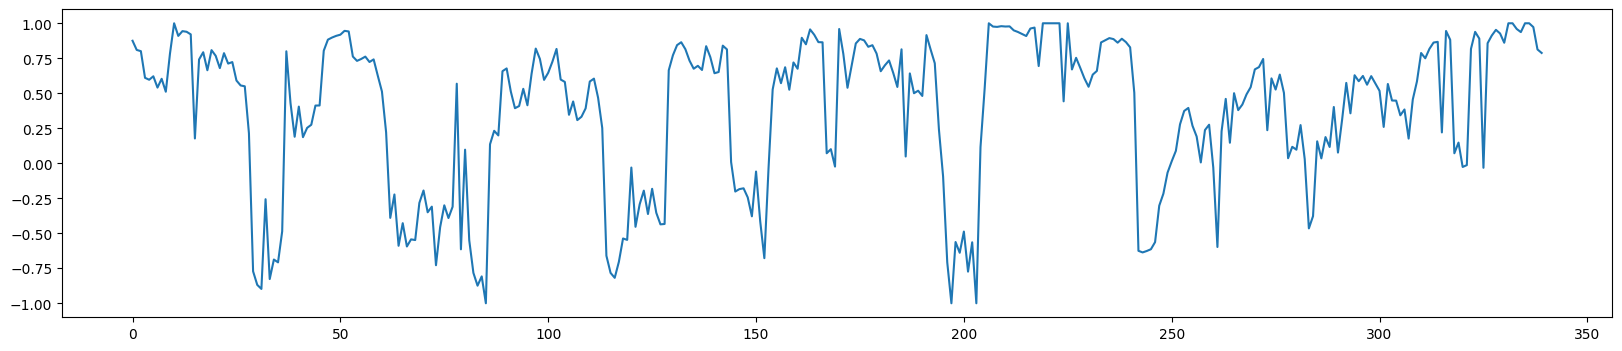

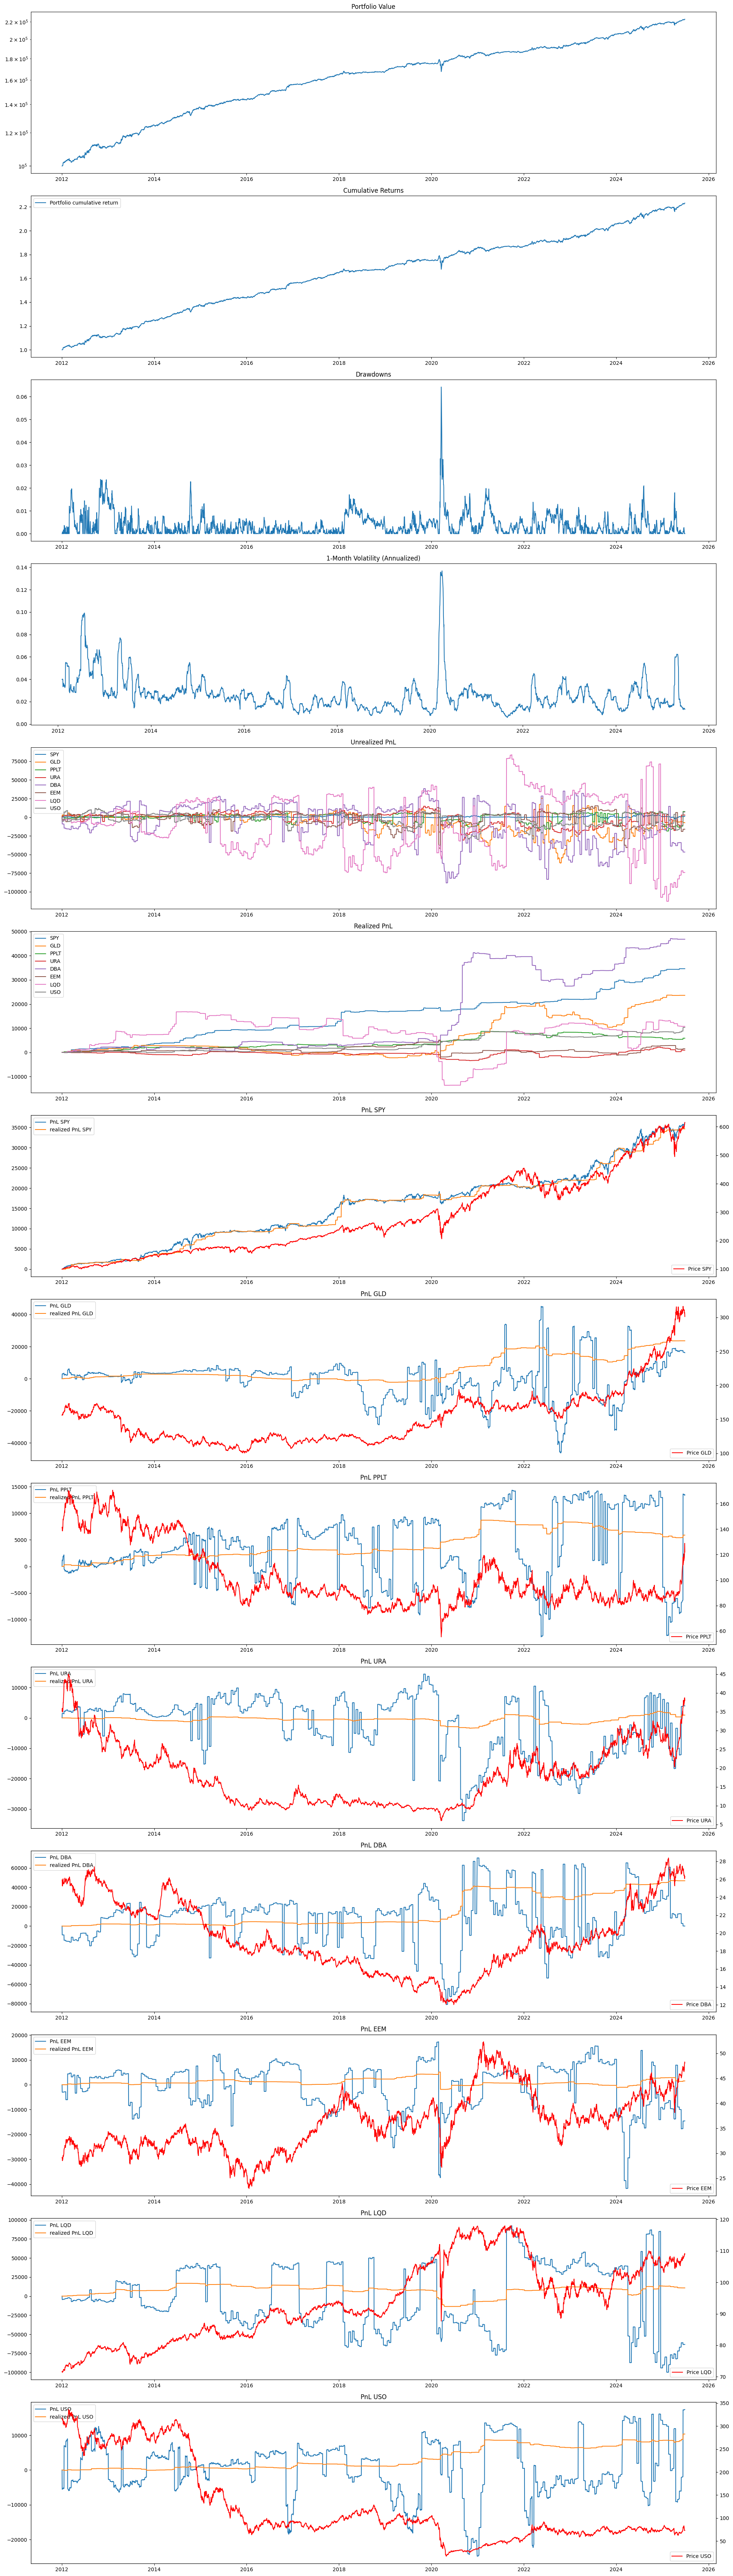

In [31]:
tickers_in_backtest = [
    'SPY', 
    # 'TLT', 
    'GLD', 
    'PPLT', 
    'URA', 
    'DBA', 
    'EEM',
    'LQD', 
    # 'IBIT',
    'USO',
]

rebalance_period = 10
ret_model_perf_tracker = []
vol_model_perf_tracker = []
leverage_tracker = []

# Price data
trading_price_data = {f: price_data[f].copy() for f in tickers_in_backtest}
start_date = pd.to_datetime('2012-01-01')
for ticker in trading_price_data:
    df = trading_price_data[ticker]
    df = df.loc[df.index >= start_date]
    trading_price_data[ticker] = df

# Trading data
trading_data = dict()
for ticker in tickers_in_backtest:
    trading_data[ticker] = risky_assets[ticker]['data']


btr = BackTester(trading_price_data)
btr.add_strategy(
    MultiAssetStrategy,
    tickers=tickers_in_backtest,
    price_data=trading_price_data,
    rebalance_period=rebalance_period,
    lookback_periods=[21, 100, 200, 252],
    dict_data=trading_data.copy(),
)
results = btr.backtest()

for key in results:
    if key == 'returns': continue
    print(f"{key}: {results[key]:.2f}")

print(f'Mean leverage: {np.mean(leverage_tracker):.2f}')

plt.figure(figsize=(20, 4))
plt.plot(leverage_tracker, label='Leverage')
plt.show()

btr.plot_results()




## END

# LIVE TRADING

In [8]:
# trading_data = {f: risky_assets[f]['data'] for f in ticker_list}

# for ticker in trading_data:
#     df = trading_data[ticker].copy()

#     plt.figure(figsize=(10, 6))
#     for period in lookback_periods:
#         plt.plot(df.index, df[f'MA_{period}'], label=period)
#     plt.legend()
#     plt.show()

## Calculate Positions

In [32]:
capital = 74444
leverage = 1.5
capital_spent = 0
lookforward_period = 50
lookback_periods=[21, 100, 200, 252]
rebalance_period=21
atr_period = 21
covariance_matrix_lookback = 252
historical_lookback_period = 252 * 2
ticker_list = [
    'SPY', 
    # 'TLT', 
    'GLD', 
    'PPLT', 
    'URA', 
    'DBA', 
    'EEM',
    'LQD', 
    'IBIT',
    'USO',
]

trading_data = {f: risky_assets[f]['data'] for f in ticker_list}


# Hierarchical Risk Parity to compute asset allocation
df_combined = pd.DataFrame()
for ticker in ticker_list:
    df_data = trading_data[ticker].copy()
    df_data = df_data.iloc[-covariance_matrix_lookback:]
    df_data['returns'] = df_data['close'].pct_change()
    df_combined[ticker] = df_data['returns']
df_combined.dropna(inplace=True)

# Exponentially weighted covariance matrix
ewma_cov = risk_models.exp_cov(df_combined, returns_data=True, span=covariance_matrix_lookback)

# Ledoit Wolf shrinkage
ledoit_wolf_cov = risk_models.CovarianceShrinkage(
    prices=df_combined.iloc[-covariance_matrix_lookback:], 
    returns_data=True
).ledoit_wolf()
cov = (ledoit_wolf_cov + ewma_cov) / 2

# HRP
hrpopt = HRPOpt(
    cov_matrix=cov
)
asset_allocation_weights = hrpopt.optimize()
# Limit weights to be between 5% and 50%
for ticker in ticker_list:
    asset_allocation_weights[ticker] = np.clip(asset_allocation_weights[ticker], 0.05, 0.5)


# ret_forecast_adjustment = dict()
# var_forecast_adjustment = dict()
sum_of_factors = 0
final_allocation_weights = dict()
for ticker in ticker_list:
    
    

    # compute positions
    df_data = trading_data[ticker].copy()
    
    
    # Limit to lookback period
    df_data = df_data.iloc[-historical_lookback_period:]
    
            
    # Forecast forward returns and volatility
    X_features = [f'MA_{period}' for period in lookback_periods]
    X_features += ['ATR']
    if 'VIX' in df_data.columns:
        X_features += ['VIX']

    df_train = df_data[X_features + ['ret_forward', 'vol_forward']].copy()
    df_train = df_train.dropna()
    X_scaler = RobustScaler()
    df_train[X_features] = X_scaler.fit_transform(df_train[X_features])
    X_train = df_train[X_features].iloc[:-1]
    X_test =  df_data[X_features].iloc[-1:]
    X_test = pd.DataFrame(X_test, columns=X_features)
    X_test[X_features] = X_scaler.transform(X_test)


    #########################
    # Vol Forecast
    # Vol scaling factor computation logic:
    #########################
    y_train = df_train['vol_forward'].iloc[:-1]
    model = LinearRegression()
    model.fit(X_train, y_train)
    vol_forecast = model.predict(X_test)[0]

    # Transform vol forecast to be between 0 and 1 as percentile of vol distribution
    # Higher vol forecast = lower vol scaling factor
    pct_rank = stats.percentileofscore(y_train, vol_forecast, kind='rank') / 100
    vol_scaling_factor = (1 - pct_rank) * 1.0

    # Connstrain vol scaling factor to be between 0.1 and 1
    vol_scaling_factor = np.clip(vol_scaling_factor, 0.1, 1.0)


    #########################
    # Ret Forecast
    #########################
    y_train = df_train['ret_forward'].iloc[:-1]
    model = LinearRegression()
    model.fit(X_train, y_train)
    ret_forecast = model.predict(X_test)[0]
    ret_scaling_factor = 1
    
    # If ret forecast is negative, short position but with 10% size
    if ret_forecast < 0:
        ret_scaling_factor = -0.1
    else:
        # If ret forecast is positive, scale long position based on percentile of historical return distribution
        y_train_pos = y_train[y_train > 0]
        pct_rank = stats.percentileofscore(y_train_pos, ret_forecast, kind='rank') / 100
        
        # Upscale ret_scaling_factor by 20% and clip between 10% and 120%
        ret_scaling_factor = pct_rank * 1.2
        ret_scaling_factor = np.clip(ret_scaling_factor, 0.1, 1.2)
    
    # Scaling factor is the geometric mean of ret_scaling_factor and vol_scaling_factor
    # We maintain the sign of the scaling factor.
    sign = 1
    if ret_scaling_factor < 0:
        sign = -1
    scaling_factor = gmean(np.abs(np.array([ret_scaling_factor, vol_scaling_factor]))) * sign
    print(ticker, ret_scaling_factor, vol_scaling_factor, scaling_factor)
    final_allocation_weights[ticker] = asset_allocation_weights[ticker] * scaling_factor

sum_allocation = np.sum([np.abs(f) for f in final_allocation_weights.values()])
for ticker in ticker_list:
    final_allocation_weights[ticker] = final_allocation_weights[ticker] / sum_allocation

for ticker in ticker_list:
    final_scaling_factor = final_allocation_weights[ticker]
    capital_allocated = capital * leverage * final_scaling_factor
    sum_of_factors += final_scaling_factor
    
    current_price = df_data.iloc[-1]['close']
    shares_to_buy = int(capital_allocated / current_price)
    capital_to_buy = shares_to_buy * current_price
    capital_spent += capital_to_buy

    print('------------------------------------------------------------------------')
    print(ticker)
    print(f'Current date:           {df_data.index[-1]}')
    print(f'Allocation:             asset = {asset_allocation_weights[ticker]:.2%}, ret = {ret_scaling_factor:.2%}, vol = {vol_scaling_factor:.2%}')
    print(f'final_scaling_factor:   {final_scaling_factor:.2%} = ${capital * leverage * final_scaling_factor:.2f}')
    print(f'shares to buy:          {shares_to_buy} = ${capital_allocated:.2f} / ${current_price:.2f}')


df_data = price_data['IB01.L'].copy()
print('------------------------------------------------------------------------')
capital_left = capital - capital_spent
cash_allocation = max(capital_left, 0) / capital
print(f'IB01.L')
print(f'capital_left:           {capital_left:.2f} = {capital_left / capital:.2%}')
print(f'allocation:             {cash_allocation:.2%}')
print(f'shares to buy:          {int(cash_allocation / df_data.iloc[-1]["close"]):.2f} = ${int(cash_allocation):.2f} / ${df_data.iloc[-1]["close"]:.2f}')
print('------------------------------------------------------------------------')

print(f'sum of factors: {sum_of_factors * leverage:.2%}')

SPY 0.5527696793002916 1.0 0.7434848211633454
GLD 1.0059701492537314 0.1169154228855721 0.3429481380766808
PPLT -0.1 0.8461538461538461 -0.29088723694136986
URA -0.1 0.1 -0.10000000000000002
DBA 0.9639999999999999 0.26302729528535973 0.5035457403802427
EEM -0.1 0.8734491315136477 -0.2955417282743078
LQD 0.24521739130434783 0.36724565756823824 0.30009168951627635
IBIT -0.1 0.1 -0.10000000000000002
USO 0.29473684210526313 0.6352357320099256 0.4326977855790698
------------------------------------------------------------------------
SPY
Current date:           2025-06-27 00:00:00
Allocation:             asset = 5.41%, ret = 29.47%, vol = 63.52%
final_scaling_factor:   11.17% = $12472.13
shares to buy:          170 = $12472.13 / $73.28
------------------------------------------------------------------------
GLD
Current date:           2025-06-27 00:00:00
Allocation:             asset = 5.52%, ret = 29.47%, vol = 63.52%
final_scaling_factor:   5.25% = $5867.91
shares to buy:          80 = $5

# PORTFOLIO TRACKING

CAGR:                   8.39%
Volatility:             7.64%
Sharpe Ratio:           1.10
Max Drawdown:          -3.21%
Total Returns:          2.75%
Total PnL:             $2011.85


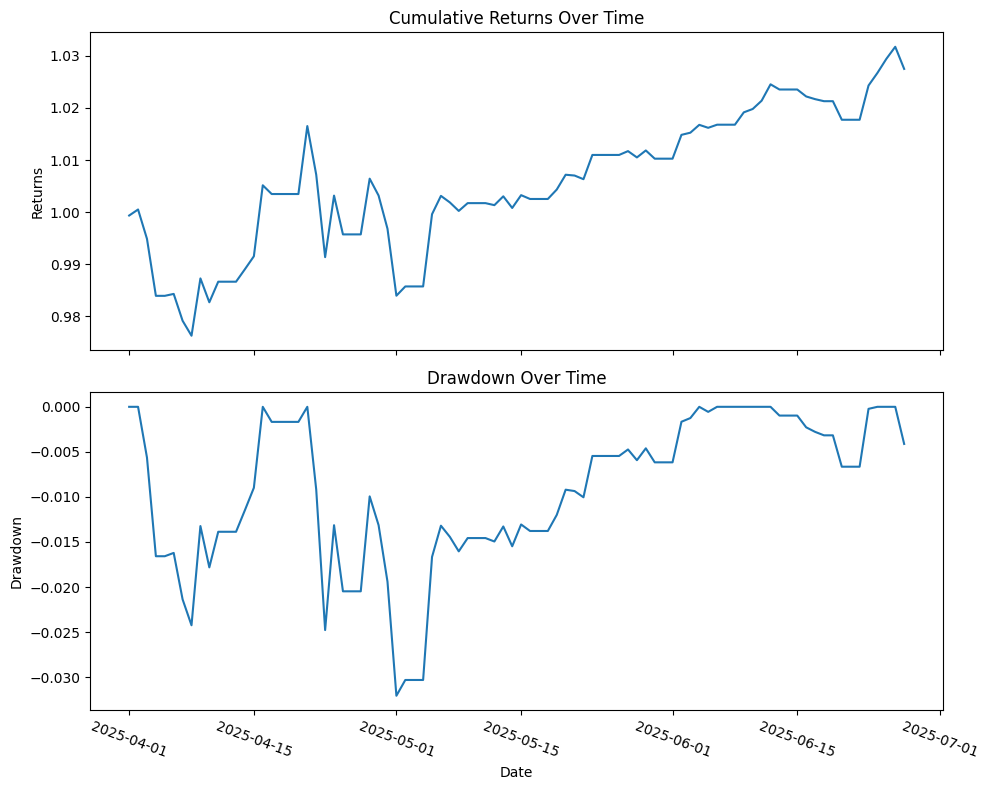

In [10]:
def compute_portfolio_value(trades_df, price_data_dict):
    """
    Compute daily portfolio value given trades and price data.
    
    trades_df: DataFrame with columns ['date', 'ticker', 'quantity', 'price', 'fees']
    price_data_dict: dict mapping ticker -> DataFrame with index 'date' and column 'close'
    
    Returns:
        portfolio_value: Series indexed by date
    """
    # Ensure date types and sort
    trades = trades_df.copy()
    trades['date'] = pd.to_datetime(trades['date'])
    trades.sort_values('date', inplace=True)

    # Determine date index range
    all_dates = pd.date_range(
        start=trades['date'].min(), 
        end=max(df.index.max() for df in price_data_dict.values()),
        freq='D'
    )
    
    # Initialize cash flow and holdings
    cash_flows = pd.Series(0.0, index=all_dates)
    holdings = {ticker: pd.Series(0.0, index=all_dates) for ticker in price_data_dict if ticker != 'CASH'}
    invested_capital = pd.Series(0.0, index=all_dates)
    
    # Process trades
    for _, row in trades.iterrows():
        dt = row['date']
        tk = row['ticker']
        qty = row['quantity']
        price = row['price']
        fees = row['fees']
        
        if tk == 'CASH':
            cash_flows.loc[dt] += qty
            invested_capital[dt:] += qty
        else:
            # Update holdings from this date onward
            holdings[tk].loc[dt:] += qty
            # Cash change: buying (positive qty) -> outflow; selling (negative qty) -> inflow
            cash_flows.loc[dt] += -qty * price - fees
    
    # Compute cumulative cash
    cash = cash_flows.cumsum()
    
    # Compute daily holdings value
    holdings_value = pd.Series(0.0, index=all_dates)
    for tk, pos in holdings.items():
        # Align prices
        # prices = price_data_dict[tk].reindex(all_dates)['close'].fillna(method='ffill')
        prices = price_data_dict[tk].reindex(all_dates)['close'].ffill()
        holdings_value += pos * prices
    
    # Total portfolio value
    portfolio_value = cash + holdings_value
    return portfolio_value, invested_capital

def compute_performance_metrics(portfolio_value, invested_capital, trading_days=252):
    """
    Compute performance metrics: CAGR, volatility, Sharpe ratio, max drawdown
    """
    cumulative_returns = portfolio_value / invested_capital

    # Daily returns
    daily_returns = cumulative_returns.pct_change().dropna()
    
    # CAGR
    total_days = (cumulative_returns.index[-1] - cumulative_returns.index[0]).days
    cagr = (cumulative_returns.iloc[-1] / cumulative_returns.iloc[0]) ** (trading_days / total_days) - 1
    
    # Volatility (annualized)
    vol = daily_returns.std() * np.sqrt(trading_days)
    
    # Sharpe ratio (assumes risk-free rate = 0)
    sharpe = cagr / vol
    
    # Max drawdown
    rolling_max = cumulative_returns.cummax()
    drawdown = (cumulative_returns - rolling_max) / rolling_max
    max_dd = drawdown.min()

    print(f'CAGR:                   {cagr:.2%}')
    print(f'Volatility:             {vol:.2%}')
    print(f'Sharpe Ratio:           {sharpe:.2f}')
    print(f'Max Drawdown:          -{-max_dd:.2%}')
    print(f'Total Returns:          {portfolio_value.iloc[-1] / invested_capital.iloc[-1] - 1:.2%}')
    print(f'Total PnL:             ${portfolio_value.iloc[-1] - invested_capital.iloc[-1]:.2f}')
    
    
    return {
        'CAGR': cagr,
        'Volatility': vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd
    }

def plot_portfolio_and_drawdown(portfolio_value, invested_capital):
    """
    Plot portfolio value and drawdown
    """
    cumulative_returns = portfolio_value / invested_capital

    # Compute drawdown
    rolling_max = cumulative_returns.cummax()
    drawdown = (cumulative_returns - rolling_max) / rolling_max
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 8))
    
    ax1.plot(cumulative_returns.index, cumulative_returns.values)
    ax1.set_title('Cumulative Returns Over Time')
    ax1.set_ylabel('Returns')
    
    ax2.plot(drawdown.index, drawdown.values)
    ax2.set_title('Drawdown Over Time')
    ax2.set_ylabel('Drawdown')
    ax2.set_xlabel('Date')
    plt.setp(ax2.get_xticklabels(), rotation=-20)
    
    plt.tight_layout()
    plt.show()

# Example usage:
trades_df = pd.read_excel('portfolio_tracker.xlsx')
# trades_df = trades_df.loc[trades_df['ticker'].isin(['SPY', 'TLT', 'GLD', 'SHV', 'CASH'])]
price_data_dict = {
    'SPY': pd.read_pickle(f'./data/raw/price/SPY_{current_date}.pkl'),
    'TLT': pd.read_pickle(f'./data/raw/price/TLT_{current_date}.pkl'),
    'GLD': pd.read_pickle(f'./data/raw/price/GLD_{current_date}.pkl'),
    'SHV': pd.read_pickle(f'./data/raw/price/SHV_{current_date}.pkl'),
    'PPLT': pd.read_pickle(f'./data/raw/price/PPLT_{current_date}.pkl'),
    'URA': pd.read_pickle(f'./data/raw/price/URA_{current_date}.pkl'),
    'USO': pd.read_pickle(f'./data/raw/price/USO_{current_date}.pkl'),
    'IBIT': pd.read_pickle(f'./data/raw/price/IBIT_{current_date}.pkl'),
    'EEM': pd.read_pickle(f'./data/raw/price/EEM_{current_date}.pkl'),
    'DBA': pd.read_pickle(f'./data/raw/price/DBA_{current_date}.pkl'),
    'IB01.L': pd.read_pickle(f'./data/raw/price/IB01.L_{current_date}.pkl'),
    'LQD': pd.read_pickle(f'./data/raw/price/LQD_{current_date}.pkl'),

}
port_val, invested_cap = compute_portfolio_value(trades_df, price_data_dict)
metrics = compute_performance_metrics(port_val, invested_cap)
plot_portfolio_and_drawdown(port_val, invested_cap)
# for key in metrics:
#     print(f'{key}: {metrics[key]:.2f}')


